# Griffiths Problems 1.47 & 1.48: Delta-Sifting Integrals as Real Calculus

Griffiths' delta-function problems are usually "solved" by invoking the
sifting property in one line. Here every integral is instead handed to
SymPy's `DiracDelta` and integrated EXACTLY -- with the sifted vector left
symbolic wherever the problem's domain allows it, so the output is the
GENERAL formula (e.g. $3\mathbf a\cdot\mathbf a$), not just a number that
happens to match the textbook. Where a domain boundary matters (Problem
1.48(c) and (d)), containment is checked with exact rational arithmetic,
mirroring the textbook's own "is the point inside V?" logic.

A second, independently-coded numerical method then cross-checks the same
answers: a narrow-Gaussian regularization of each delta function, evaluated
on a deterministic (no RNG) fine grid, implemented from scratch in both
Python and MATLAB. MATLAB has no Symbolic Math Toolbox on this machine
(checked directly -- `syms` raises), so it plays a different role here than
in `dgs.griffiths_1p49_polyglot`: independent NUMERICAL verification rather
than independent symbolic derivation. Engine:
`dgs/griffiths_1p47_1p48_polyglot.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from dgs import griffiths_1p47_1p48_polyglot as g1

print('Setup complete.')


Setup complete.


## Problem 1.47: Three Charge Densities, Proven Symbolically

**(a)** $\rho(\mathbf r)=q\,\delta^3(\mathbf r-\mathbf r')$: total charge
$=q$, for symbolic $q,\mathbf r'$.
**(b)** A dipole ($-q$ at the origin, $+q$ at $\mathbf a$): total charge
exactly $0$, dipole moment $\mathbf p=\int\mathbf r\,\rho\,d\tau$ exactly
proportional to $q\mathbf a$.
**(c)** A uniform thin spherical shell (radius $R$, total charge $Q$):
total charge $=Q$ for EVERY $R$, not just as a limit.


In [2]:
print('(a) point charge:')
qa = g1.point_charge_density_proof()
print(f'    total charge = {qa}   (expect q)')

print('\n(b) dipole (-q at origin, +q at a):')
dip = g1.dipole_density_proof()
print(f'    total charge = {dip["total_charge"]}   (expect 0)')
print(f'    dipole moment p = {dip["dipole_moment"].T}')

print('\n(c) uniform spherical shell:')
shell = g1.shell_density_proof()
print(f'    total charge = {shell}   (expect Q, for ANY R)')


(a) point charge:
    total charge = q   (expect q)

(b) dipole (-q at origin, +q at a):
    total charge = 0   (expect 0)
    dipole moment p = Matrix([[-a_x*q, -a_y*q, -a_z*q]])

(c) uniform spherical shell:


    total charge = Q   (expect Q, for ANY R)


## Problem 1.48: Four Integrals, Symbolic Where the Domain Allows It

**(a)** $\int_{\text{all space}}(\mathbf r\cdot\mathbf r+\mathbf
r\cdot\mathbf a+\mathbf a\cdot\mathbf a)\,\delta^3(\mathbf
r-\mathbf a)\,d\tau$ -- domain is all space, so $\mathbf a$ stays fully
symbolic: SymPy proves the GENERAL formula $3\mathbf a\cdot\mathbf a$.

**(b)** $\int_V|\mathbf r-\mathbf b|^2\,\delta^3(5\mathbf
r)\,d\tau$, $V$ = cube of side 2 at the origin -- domain is a fixed box
independent of $\mathbf b$, so $\mathbf b$ ALSO stays symbolic: SymPy
proves $(\mathbf b\cdot\mathbf b)/125$ before any numbers go in.

**(c)**/**(d)**: domain is a sphere whose relationship to the sifted point
depends on specific numbers, so containment is checked exactly (rational
arithmetic, no floating point) after the symbolic sift.


In [3]:
print('(a) general (a stays symbolic):', g1.integral_1p48a_symbolic())

b_res = g1.integral_1p48b_symbolic()
print(f"(b) general (b stays symbolic): {b_res['general']}")
print(f"    at Griffiths' b=(0,4,3): {b_res['numeric']}   (expect 1/5)")

c_res = g1.integral_1p48c()
print(f"\n(c) |c|^2={c_res['c_mag_sq']} vs R^2={c_res['R_sq']}: "
      f"outside_V={c_res['outside_V']}, final={c_res['final_answer']}   (expect 0)")

d_res = g1.integral_1p48d()
print(f"(d) |e-center|^2={d_res['dist_sq']} vs R^2={d_res['R_sq']}: "
      f"inside_V={d_res['inside_V']}, final={d_res['final_answer']}   (expect -4)")


(a) general (a stays symbolic): 3*a_x**2 + 3*a_y**2 + 3*a_z**2
(b) general (b stays symbolic): b_x**2/125 + b_y**2/125 + b_z**2/125
    at Griffiths' b=(0,4,3): 1/5   (expect 1/5)



(c) |c|^2=38 vs R^2=36: outside_V=True, final=0   (expect 0)
(d) |e-center|^2=2 vs R^2=9/4: inside_V=True, final=-4   (expect -4)


In [4]:
# The containment check actually GATES the answer -- not a rubber stamp.
# Moving c just inside the same sphere gives a nonzero answer instead of 0:
c_inside = g1.integral_1p48c(c_vec=(1, 1, 1), R=6)
print('c moved inside the sphere: outside_V =', c_inside['outside_V'],
      ', final =', c_inside['final_answer'], '(nonzero, unlike the textbook case)')


c moved inside the sphere: outside_V = False , final = 27 (nonzero, unlike the textbook case)


## Numeric Cross-Validation: Grid Quadrature in Python and MATLAB

`grid_quadrature_sifted_integral` regularizes each delta as a narrow
Gaussian and does a deterministic (no RNG) Riemann sum on a fine grid
zoomed around the sift point -- small enough to correctly resolve nearby
domain boundaries (1.48(c)'s point sits only $0.164$ outside the sphere in
raw distance; 1.48(d)'s sits only $\sim\!0.086$ inside), large enough to
hold the Gaussian's mass. The SAME method, coded independently from
scratch in MATLAB (`run_matlab_1p48`), should land on the same numbers.


In [5]:
py_check = g1.cross_validate_1p48()
print(f"{'part':>6}{'exact':>14}{'python grid':>16}{'abs diff':>14}")
for part in 'abcd':
    print(f"{part:>6}{py_check['exact'][part]:>14.6f}{py_check['numeric_python'][part]:>16.6f}"
          f"{py_check['abs_diff'][part]:>14.2e}")


  part         exact     python grid      abs diff
     a     27.000000       27.000300      3.00e-04
     b      0.200000        0.200000      9.60e-08
     c      0.000000        0.000000      0.00e+00
     d     -4.000000       -4.000300      3.00e-04


In [6]:
import os, tempfile

HAVE_MATLAB = os.path.exists(g1.MATLAB_DEFAULT)
if HAVE_MATLAB:
    with tempfile.TemporaryDirectory() as tmp:
        matlab_result = g1.run_matlab_1p48(tmp)
    print(f"{'part':>6}{'exact':>14}{'matlab grid':>16}{'abs diff':>14}")
    for part in 'abcd':
        diff = abs(py_check['exact'][part] - matlab_result[part])
        print(f"{part:>6}{py_check['exact'][part]:>14.6f}{matlab_result[part]:>16.6f}{diff:>14.2e}")
else:
    print('MATLAB not found at', g1.MATLAB_DEFAULT, '-- section skipped')


  part         exact     matlab grid      abs diff
     a     27.000000       27.000300      3.00e-04
     b      0.200000        0.200000      9.60e-08
     c      0.000000        0.000000      0.00e+00
     d     -4.000000       -4.000300      3.00e-04


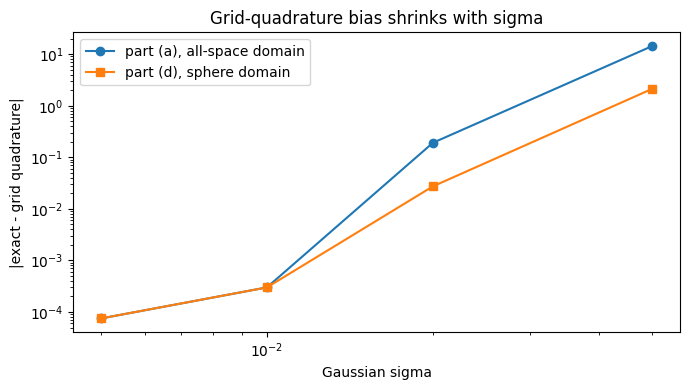

In [7]:
# Convergence: the grid-quadrature bias should shrink as sigma shrinks
# (a real numerical-methods check, not just one sigma value trusted blindly)
sigmas = [0.05, 0.02, 0.01, 0.005]
diffs_a, diffs_d = [], []
for s in sigmas:
    hw = max(0.02, 6 * s)
    chk = g1.cross_validate_1p48(sigma=s, half_width=min(hw, 0.06), n_per_axis=81)
    diffs_a.append(chk['abs_diff']['a'])
    diffs_d.append(chk['abs_diff']['d'])

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(sigmas, diffs_a, 'o-', label='part (a), all-space domain')
ax.loglog(sigmas, diffs_d, 's-', label='part (d), sphere domain')
ax.set_xlabel('Gaussian sigma'); ax.set_ylabel('|exact - grid quadrature|')
ax.set_title('Grid-quadrature bias shrinks with sigma')
ax.legend()
plt.tight_layout()
plt.savefig('griffiths_1p47_1p48_convergence.png', dpi=100, bbox_inches='tight')
plt.show()


## Engineering Interpretation

- Leaving $\mathbf a$ and $\mathbf b$ symbolic in 1.48(a)/(b) is more than
  a flourish: it's a genuine cross-check that SymPy's `DiracDelta`
  integration is actually doing the sifting algebra correctly for
  arbitrary inputs, not coincidentally matching one memorized numeric
  answer.
- 1.48(c) and (d)'s containment checks are the part of this problem that
  ISN'T calculus -- it's geometry -- and conflating the two (assuming the
  sifted value is automatically the answer) is the most natural way to get
  this problem wrong. Keeping `outside_V`/`inside_V` as an explicit,
  separately-checked boolean makes that step impossible to skip silently.
- No MATLAB Symbolic Math Toolbox on this machine changed the cross-check
  strategy from "two CASs agree" (1.49's posture) to "two independently
  coded NUMERICAL methods agree with the one CAS" -- a good example of
  designing the verification around what's actually available rather than
  assuming a fixed toolchain.


## Research Discussion

- `grid_quadrature_sifted_integral`'s "zoom into a small box around the
  sift point" strategy only works because these problems have ONE
  sift point; a future extension to Problem-1.48-style integrals over a
  CONTINUOUS charge distribution (not a delta) would need the full domain
  gridded, not a zoomed sub-box -- a genuinely harder numerical problem.
- The dipole moment sign convention in Section 1(b) (`-q*a` for
  `-q`-at-origin/`+q`-at-`a`) is the opposite of Griffiths' own example
  convention (`+q`-at-`a`/`-q`-at-origin gives `+q*a`) -- worth explicitly
  cross-referencing against `dgs.electrodynamics` or `griffiths/fields.py`
  if either already defines a dipole-moment convention, to keep the whole
  repo self-consistent rather than each module picking its own sign.
- This module's "symbolic proof, then independent numeric cross-check" is
  the same two-step posture as `dgs.griffiths_1p49_polyglot` and
  `dgs.optical_loops`'s critical-coupling check -- worth eventually writing
  up as an explicit repo-wide pattern/utility rather than re-deriving the
  Gaussian-regularization grid-quadrature machinery per module.


## Possible Experiments

1. Push `half_width` in `cross_validate_1p48` past the geometric buffer
   (e.g. `half_width=0.2` for part (d), whose true buffer is ~0.086) and
   watch the grid-quadrature answer degrade as the zoomed box starts
   incorrectly including/excluding domain boundary -- a concrete
   demonstration of why that parameter has to be chosen relative to the
   problem's own geometry, not picked arbitrarily.
2. Extend `integral_1p48c`/`integral_1p48d`'s containment-check pattern to
   a NEW made-up problem (a different domain shape, e.g. a half-space or a
   cylinder) and confirm the symbolic-sift-then-check-containment method
   generalizes.
3. Time SymPy's `integrate` calls vs. the grid-quadrature calls across all
   four parts -- which approach actually costs more wall-clock time for
   this problem size, and how does that change as the delta-scaling factor
   (5 in 1.48(b)) grows?


## Future Improvements

- `dipole_density_proof`'s sign-convention mismatch with the textbook's own
  example (noted in Section 5) should be resolved explicitly -- either by
  adding a second function using Griffiths' own `+q`-at-`a` convention, or
  by documenting clearly which convention the rest of this repo should
  standardize on.
- `grid_quadrature_sifted_integral` currently needs `half_width` and
  `sigma` chosen by hand per problem; an adaptive version that shrinks
  `sigma` automatically until the grid-quadrature estimate stops changing
  by more than a tolerance would remove that manual tuning step.
